<a href="https://colab.research.google.com/github/romaxod/ML-HW4-FUULXOD/blob/main/model_experiment_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iteration 1 - MLP baseline (MLP_Training)



In [1]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/api/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

Mounted at /content/drive


In [2]:
!mkdir -p data
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge -p data
!cd data && unzip -o "*.zip" >/dev/null && echo "unzipped" && ls

100% 285M/285M [00:01<00:00, 202MB/s]

unzipped
challenges-in-representation-learning-facial-expression-recognition-challenge.zip
example_submission.csv
fer2013.tar.gz
icml_face_data.csv
test.csv
train.csv


## 1. Setup

In [3]:
# --- install + imports ---
!pip -q install wandb
import os, math, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
torch.manual_seed(42); np.random.seed(42)

device: cuda


## 2. Dataset (Kaggle)

In [12]:

IMG_SIZE, NUM_CLASSES = 48, 7
EMOTIONS = {0:"Angry",1:"Disgust",2:"Fear",3:"Happy",4:"Sad",5:"Surprise",6:"Neutral"}
FER_MEAN, FER_STD = 0.507, 0.255

def parse_pixels(s):
    return np.fromstring(s, dtype=np.float32, sep=" ").reshape(IMG_SIZE, IMG_SIZE)

class FERDataset(Dataset):
    def __init__(self, imgs, labels, tf):
        self.imgs, self.labels, self.tf = imgs, labels, tf
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        img = self.tf(self.imgs[i].astype(np.uint8))
        if self.labels is None: return img
        return img, int(self.labels[i])

def build_tf(train, augment, normalize=True):
    t = [transforms.ToPILImage()]
    if train and augment:
        t += [transforms.RandomHorizontalFlip(),
              transforms.RandomRotation(10),
              transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0))]
    t += [transforms.ToTensor()]
    if normalize: t += [transforms.Normalize([FER_MEAN], [FER_STD])]
    return transforms.Compose(t)

def load_data(csv_path="data/icml_face_data.csv", batch_size=128, augment=False):
    df = pd.read_csv(csv_path); df.columns = [c.strip() for c in df.columns]
    def split(usage):
        sub = df[df["Usage"] == usage]
        X = np.stack([parse_pixels(p) for p in sub["pixels"].values])
        y = sub["emotion"].values.astype(np.int64)
        return X, y
    Xtr,ytr = split("Training"); Xva,yva = split("PublicTest"); Xte,yte = split("PrivateTest")
    tr = FERDataset(Xtr,ytr, build_tf(True,  augment))
    va = FERDataset(Xva,yva, build_tf(False, False))
    te = FERDataset(Xte,yte, build_tf(False, False))
    return (DataLoader(tr, batch_size, shuffle=True),
            DataLoader(va, batch_size, shuffle=False),
            DataLoader(te, batch_size, shuffle=False))

## 3. Log in to W&B

In [13]:

wandb.login()

True

## 4. Helpers (train / eval / sanity)

In [14]:

def train_one_epoch(model, loader, opt, crit):
    model.train(); tl=correct=n=0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad(); out = model(x); loss = crit(out,y)
        loss.backward(); opt.step()
        tl += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return tl/n, correct/n

@torch.no_grad()
def evaluate(model, loader, crit):
    model.eval(); tl=correct=n=0; preds=[]; tgts=[]
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        out = model(x); loss = crit(out,y)
        tl += loss.item()*x.size(0); p = out.argmax(1)
        correct += (p==y).sum().item(); n += x.size(0)
        preds += p.cpu().tolist(); tgts += y.cpu().tolist()
    return tl/n, correct/n, preds, tgts

In [15]:

def sanity_checks(model):
    model = model.to(device)
    x = torch.randn(8,1,IMG_SIZE,IMG_SIZE, device=device)
    out = model(x)
    assert out.shape == (8, NUM_CLASSES), out.shape
    print("forward shape OK:", tuple(out.shape))
    y = torch.randint(0, NUM_CLASSES, (8,), device=device)
    loss = nn.CrossEntropyLoss()(model(x), y)
    print(f"loss@init = {loss.item():.3f}  (expect ~ln(7) = {math.log(7):.3f})")
    model.zero_grad(); loss.backward()
    missing = [n for n,p in model.named_parameters() if p.requires_grad and p.grad is None]
    print("params missing grad:", missing if missing else "none -> backward OK")

## 5. Model + sanity check

In [16]:

class MLP(nn.Module):
    """Flatten 48x48 -> 2304 and run dense layers. Throws away all 2-D
    structure, so it cannot learn good facial features: our underfit baseline."""
    def __init__(self, hidden=(512,256), dropout=0.0):
        super().__init__()
        layers, d = [], IMG_SIZE*IMG_SIZE
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            if dropout > 0: layers.append(nn.Dropout(dropout))
            d = h
        self.net  = nn.Sequential(*layers)
        self.head = nn.Linear(d, NUM_CLASSES)
    def forward(self, x):
        return self.head(self.net(torch.flatten(x, 1)))

sanity_checks(MLP())

forward shape OK: (8, 7)
loss@init = 1.923  (expect ~ln(7) = 1.946)
params missing grad: none -> backward OK


## 6. Training routine (W&B logging)

In [17]:

import numpy as np
HISTORY, SUMMARY, CONF = {}, [], {}

GROUP   = "MLP_Training"
PROJECT = "fer2013-emotion"

def train_run(run_name, model, epochs, lr, batch_size, augment,
              weight_decay=0.0, optimizer="adam", label_smoothing=0.0, save_path=None):
    tr, va, te = load_data(batch_size=batch_size, augment=augment)
    model = model.to(device)
    n_params = sum(p.numel() for p in model.parameters())
    run = wandb.init(project=PROJECT, group=GROUP, name=run_name, reinit=True,
                     config=dict(model_type=GROUP.replace("_Training",""), config=run_name,
                                 lr=lr, batch_size=batch_size, epochs=epochs, augment=augment,
                                 weight_decay=weight_decay, optimizer=optimizer,
                                 label_smoothing=label_smoothing, n_params=n_params))
    wandb.watch(model, log="all", log_freq=100)
    opt = (torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
           if optimizer == "adam" else
           torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay))
    crit = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    hist = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": [], "gap": []}
    best_val, best_state = 0.0, None
    for ep in range(1, epochs + 1):
        trl, tra = train_one_epoch(model, tr, opt, crit)
        val, vaa, vp, vt = evaluate(model, va, crit)
        wandb.log({"epoch": ep, "train/loss": trl, "train/acc": tra, "val/loss": val,
                   "val/acc": vaa, "overfit_gap": tra - vaa, "lr": opt.param_groups[0]["lr"]})
        for k, v in zip(hist, [tra, vaa, trl, val, tra - vaa]): hist[k].append(v)
        if vaa > best_val:
            best_val = vaa
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"ep{ep:02d}  train {tra:.3f}  val {vaa:.3f}  gap {tra-vaa:+.3f}")

    if best_state is not None: model.load_state_dict(best_state)
    tel, tea, tp, tt = evaluate(model, te, crit)
    from sklearn.metrics import f1_score, classification_report
    cls = [EMOTIONS[i] for i in range(NUM_CLASSES)]
    f1 = f1_score(tt, tp, average="macro")
    wandb.run.summary["best_val_acc"] = best_val
    wandb.run.summary["test_acc"] = tea
    wandb.run.summary["test_f1"] = f1
    rep = classification_report(tt, tp, target_names=cls, output_dict=True, zero_division=0)
    tbl = wandb.Table(columns=["class", "precision", "recall", "f1", "support"])
    for c in cls:
        r = rep[c]; tbl.add_data(c, r["precision"], r["recall"], r["f1-score"], r["support"])
    wandb.log({"val/confusion_matrix":  wandb.plot.confusion_matrix(y_true=vt, preds=vp, class_names=cls),
               "test/confusion_matrix": wandb.plot.confusion_matrix(y_true=tt, preds=tp, class_names=cls),
               "test/per_class_report": tbl})

    HISTORY[run_name] = hist
    CONF[run_name] = (np.array(tt), np.array(tp))
    SUMMARY.append(dict(run=run_name, params=n_params, best_val_acc=best_val,
                        test_acc=tea, test_f1=f1, final_gap=hist["gap"][-1]))
    print(f"BEST val_acc={best_val:.4f}  TEST acc={tea:.4f}  f1={f1:.4f}")
    if save_path is not None: torch.save(model.state_dict(), save_path); print("saved ->", save_path)
    wandb.finish()
    return best_val, tea

## 7. Manual hyperparameter tuning

In [18]:
# --- manual hyperparameter tuning: a few configs, each logged as its own run ---
mlp_configs = [
    dict(run_name="MLP h=[256] lr=1e-3",            hidden=(256,),    dropout=0.0, lr=1e-3),
    dict(run_name="MLP h=[512,256] lr=1e-3",        hidden=(512,256), dropout=0.0, lr=1e-3),
    dict(run_name="MLP h=[512,256] lr=5e-4 do=0.3", hidden=(512,256), dropout=0.3, lr=5e-4),
]
for c in mlp_configs:
    model = MLP(hidden=c["hidden"], dropout=c["dropout"])
    train_run(c["run_name"], model, epochs=30, lr=c["lr"], batch_size=128, augment=False)

ep01  train 0.346  val 0.379  gap -0.034
ep02  train 0.402  val 0.401  gap +0.001
ep03  train 0.427  val 0.400  gap +0.028
ep04  train 0.453  val 0.398  gap +0.055
ep05  train 0.473  val 0.414  gap +0.059
ep06  train 0.498  val 0.414  gap +0.084
ep07  train 0.519  val 0.405  gap +0.114
ep08  train 0.543  val 0.420  gap +0.123
ep09  train 0.568  val 0.418  gap +0.150
ep10  train 0.590  val 0.416  gap +0.174
ep11  train 0.608  val 0.418  gap +0.190
ep12  train 0.633  val 0.427  gap +0.206
ep13  train 0.657  val 0.425  gap +0.232
ep14  train 0.675  val 0.421  gap +0.254
ep15  train 0.694  val 0.426  gap +0.268
ep16  train 0.709  val 0.411  gap +0.297
ep17  train 0.727  val 0.440  gap +0.287
ep18  train 0.743  val 0.420  gap +0.324
ep19  train 0.758  val 0.432  gap +0.326
ep20  train 0.781  val 0.435  gap +0.347
ep21  train 0.787  val 0.435  gap +0.353
ep22  train 0.802  val 0.429  gap +0.372
ep23  train 0.814  val 0.429  gap +0.385
ep24  train 0.822  val 0.437  gap +0.385
ep25  train 0.83

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▁▂▂▂▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/acc,▁▂▂▂▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇█████
train/loss,█▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val/acc,▁▃▃▃▅▅▄▆▅▅▅▆▆▆▆▅█▆▇▇▇▇▇█▇▆▇▆▆▆
val/loss,▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▆▆▆▇███
best_val_acc,0.43996
epoch,30
lr,0.001
overfit_gap,0.45077


ep01  train 0.341  val 0.384  gap -0.043
ep02  train 0.399  val 0.397  gap +0.002
ep03  train 0.433  val 0.415  gap +0.018
ep04  train 0.466  val 0.410  gap +0.056
ep05  train 0.490  val 0.436  gap +0.054
ep06  train 0.519  val 0.443  gap +0.076
ep07  train 0.556  val 0.433  gap +0.123
ep08  train 0.586  val 0.429  gap +0.157
ep09  train 0.620  val 0.442  gap +0.178
ep10  train 0.655  val 0.446  gap +0.210
ep11  train 0.694  val 0.440  gap +0.254
ep12  train 0.726  val 0.441  gap +0.285
ep13  train 0.754  val 0.453  gap +0.301
ep14  train 0.782  val 0.445  gap +0.337
ep15  train 0.806  val 0.450  gap +0.356
ep16  train 0.828  val 0.443  gap +0.385
ep17  train 0.850  val 0.457  gap +0.393
ep18  train 0.863  val 0.454  gap +0.409
ep19  train 0.878  val 0.457  gap +0.421
ep20  train 0.883  val 0.443  gap +0.440
ep21  train 0.894  val 0.456  gap +0.438
ep22  train 0.905  val 0.458  gap +0.446
ep23  train 0.907  val 0.452  gap +0.455
ep24  train 0.912  val 0.455  gap +0.457
ep25  train 0.90

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▂▂▃▃▄▄▄▅▅▆▆▆▇▇▇▇▇▇▇████████
train/acc,▁▂▂▂▃▃▄▄▄▅▅▆▆▆▆▇▇▇▇▇██████████
train/loss,█▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▄▃▆▇▆▅▆▇▆▆█▇▇▇███▇██▇█▇█▇█▇▆
val/loss,▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▄▄▅▅▅▆▆▇▇▇▇███
best_val_acc,0.45807
epoch,30
lr,0.001
overfit_gap,0.48495


ep01  train 0.326  val 0.377  gap -0.050
ep02  train 0.373  val 0.390  gap -0.017
ep03  train 0.393  val 0.413  gap -0.020
ep04  train 0.414  val 0.405  gap +0.010
ep05  train 0.428  val 0.422  gap +0.005
ep06  train 0.439  val 0.425  gap +0.013
ep07  train 0.453  val 0.435  gap +0.018
ep08  train 0.471  val 0.440  gap +0.031
ep09  train 0.481  val 0.447  gap +0.035
ep10  train 0.491  val 0.448  gap +0.043
ep11  train 0.508  val 0.450  gap +0.058
ep12  train 0.518  val 0.453  gap +0.065
ep13  train 0.532  val 0.459  gap +0.073
ep14  train 0.544  val 0.459  gap +0.085
ep15  train 0.556  val 0.464  gap +0.092
ep16  train 0.568  val 0.462  gap +0.106
ep17  train 0.574  val 0.473  gap +0.102
ep18  train 0.590  val 0.466  gap +0.124
ep19  train 0.597  val 0.456  gap +0.141
ep20  train 0.609  val 0.473  gap +0.136
ep21  train 0.619  val 0.467  gap +0.152
ep22  train 0.630  val 0.471  gap +0.159
ep23  train 0.641  val 0.461  gap +0.180
ep24  train 0.647  val 0.473  gap +0.174
ep25  train 0.65

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇█████
train/acc,▁▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
train/loss,█▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val/acc,▁▂▃▃▄▄▅▅▆▆▆▆▆▆▇▆▇▇▆▇▇▇▆▇█▇▇█▇█
val/loss,█▆▅▄▃▃▂▂▂▁▁▂▂▂▁▂▂▃▃▂▃▄▅▅▆▆▆▇█▇
best_val_acc,0.48565
epoch,30
lr,0.0005
overfit_gap,0.20643


In [19]:

train_run("MLP h=[64] lr=1e-3", MLP(hidden=(64,)), epochs=30, lr=1e-3, batch_size=128, augment=False)
train_run("MLP h=[512,256,128] lr=1e-3", MLP(hidden=(512,256,128)), epochs=30, lr=1e-3, batch_size=128, augment=False)

train_run("MLP h=[512,256] do=0.5 lr=5e-4", MLP(hidden=(512,256), dropout=0.5), epochs=30, lr=5e-4, batch_size=128, augment=False)
train_run("MLP h=[512,256] do=0.3 wd=1e-4 lr=5e-4", MLP(hidden=(512,256), dropout=0.3), epochs=30, lr=5e-4, batch_size=128, augment=False, weight_decay=1e-4)


train_run("MLP h=[512,256] do=0.3 aug lr=5e-4", MLP(hidden=(512,256), dropout=0.3), epochs=30, lr=5e-4, batch_size=128, augment=True)

ep01  train 0.338  val 0.372  gap -0.034
ep02  train 0.396  val 0.391  gap +0.006
ep03  train 0.419  val 0.390  gap +0.029
ep04  train 0.440  val 0.398  gap +0.042
ep05  train 0.454  val 0.405  gap +0.049
ep06  train 0.466  val 0.412  gap +0.054
ep07  train 0.483  val 0.404  gap +0.079
ep08  train 0.494  val 0.427  gap +0.067
ep09  train 0.512  val 0.412  gap +0.101
ep10  train 0.518  val 0.419  gap +0.100
ep11  train 0.534  val 0.414  gap +0.120
ep12  train 0.539  val 0.416  gap +0.123
ep13  train 0.550  val 0.416  gap +0.134
ep14  train 0.563  val 0.414  gap +0.149
ep15  train 0.569  val 0.411  gap +0.158
ep16  train 0.579  val 0.418  gap +0.161
ep17  train 0.594  val 0.421  gap +0.173
ep18  train 0.593  val 0.406  gap +0.188
ep19  train 0.603  val 0.415  gap +0.188
ep20  train 0.610  val 0.407  gap +0.203
ep21  train 0.618  val 0.415  gap +0.203
ep22  train 0.631  val 0.412  gap +0.219
ep23  train 0.636  val 0.421  gap +0.215
ep24  train 0.651  val 0.410  gap +0.241
ep25  train 0.64

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▃▃▃▄▃▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
train/acc,▁▂▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇████
train/loss,█▇▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val/acc,▁▃▃▄▅▆▅█▆▇▆▇▇▆▆▇▇▅▇▆▆▆▇▆▅▆▅▆▆▆
val/loss,▂▂▂▁▁▁▂▁▂▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▇▆▇▇██
best_val_acc,0.42658
epoch,30
lr,0.001
overfit_gap,0.27421


ep01  train 0.340  val 0.389  gap -0.049
ep02  train 0.396  val 0.391  gap +0.005
ep03  train 0.428  val 0.418  gap +0.010
ep04  train 0.463  val 0.433  gap +0.030
ep05  train 0.486  val 0.447  gap +0.039
ep06  train 0.518  val 0.451  gap +0.067
ep07  train 0.549  val 0.446  gap +0.103
ep08  train 0.583  val 0.437  gap +0.147
ep09  train 0.621  val 0.451  gap +0.170
ep10  train 0.649  val 0.459  gap +0.190
ep11  train 0.683  val 0.447  gap +0.235
ep12  train 0.716  val 0.448  gap +0.269
ep13  train 0.744  val 0.448  gap +0.297
ep14  train 0.772  val 0.459  gap +0.313
ep15  train 0.801  val 0.463  gap +0.338
ep16  train 0.823  val 0.444  gap +0.379
ep17  train 0.837  val 0.455  gap +0.382
ep18  train 0.855  val 0.439  gap +0.415
ep19  train 0.865  val 0.450  gap +0.415
ep20  train 0.874  val 0.451  gap +0.423
ep21  train 0.883  val 0.458  gap +0.425
ep22  train 0.891  val 0.454  gap +0.437
ep23  train 0.910  val 0.456  gap +0.454
ep24  train 0.906  val 0.442  gap +0.464
ep25  train 0.91

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▂▂▃▃▄▄▄▅▅▆▆▆▇▇▇▇▇▇▇████████
train/acc,▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇▇▇▇█████████
train/loss,█▇▇▇▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/acc,▁▁▄▅▆▇▆▆▇█▇▇▇██▆▇▆▇▇█▇▇▆▇▇██▇▆
val/loss,▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▄▄▄▅▅▆▇▆▇▆▇▇▇██
best_val_acc,0.46308
epoch,30
lr,0.001
overfit_gap,0.48049


ep01  train 0.301  val 0.357  gap -0.056
ep02  train 0.345  val 0.385  gap -0.041
ep03  train 0.361  val 0.392  gap -0.031
ep04  train 0.377  val 0.395  gap -0.018
ep05  train 0.385  val 0.406  gap -0.021
ep06  train 0.393  val 0.414  gap -0.021
ep07  train 0.402  val 0.426  gap -0.024
ep08  train 0.408  val 0.425  gap -0.017
ep09  train 0.416  val 0.416  gap +0.001
ep10  train 0.423  val 0.425  gap -0.002
ep11  train 0.427  val 0.417  gap +0.010
ep12  train 0.433  val 0.428  gap +0.005
ep13  train 0.444  val 0.430  gap +0.014
ep14  train 0.446  val 0.424  gap +0.022
ep15  train 0.458  val 0.438  gap +0.021
ep16  train 0.460  val 0.438  gap +0.022
ep17  train 0.469  val 0.445  gap +0.024
ep18  train 0.469  val 0.443  gap +0.026
ep19  train 0.478  val 0.434  gap +0.043
ep20  train 0.477  val 0.446  gap +0.032
ep21  train 0.484  val 0.449  gap +0.035
ep22  train 0.491  val 0.441  gap +0.050
ep23  train 0.494  val 0.449  gap +0.046
ep24  train 0.501  val 0.446  gap +0.056
ep25  train 0.50

...

ep01  train 0.326  val 0.373  gap -0.047
ep02  train 0.371  val 0.398  gap -0.028
ep03  train 0.396  val 0.405  gap -0.009
ep04  train 0.414  val 0.409  gap +0.005
ep05  train 0.425  val 0.424  gap +0.000
ep06  train 0.442  val 0.419  gap +0.023
ep07  train 0.451  val 0.420  gap +0.032
ep08  train 0.466  val 0.434  gap +0.032
ep09  train 0.477  val 0.442  gap +0.035
ep10  train 0.495  val 0.446  gap +0.048
ep11  train 0.500  val 0.447  gap +0.054
ep12  train 0.511  val 0.439  gap +0.073
ep13  train 0.525  val 0.452  gap +0.072
ep14  train 0.535  val 0.447  gap +0.087
ep15  train 0.546  val 0.443  gap +0.104
ep16  train 0.559  val 0.457  gap +0.102
ep17  train 0.568  val 0.454  gap +0.114
ep18  train 0.582  val 0.456  gap +0.126
ep19  train 0.589  val 0.459  gap +0.130
ep20  train 0.602  val 0.459  gap +0.143
ep21  train 0.610  val 0.459  gap +0.151
ep22  train 0.616  val 0.463  gap +0.154
ep23  train 0.625  val 0.469  gap +0.156
ep24  train 0.638  val 0.466  gap +0.172
ep25  train 0.64

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇▇████
train/acc,▁▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████
train/loss,█▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val/acc,▁▃▃▃▄▄▄▅▆▆▆▅▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇█
val/loss,█▆▅▄▃▃▂▂▂▁▁▁▁▂▁▂▃▃▃▂▃▃▃▄▅▄▆▆▇▆
best_val_acc,0.47673
epoch,30
lr,0.0005
overfit_gap,0.19842


ep01  train 0.303  val 0.351  gap -0.048
ep02  train 0.334  val 0.374  gap -0.040
ep03  train 0.350  val 0.387  gap -0.038
ep04  train 0.360  val 0.392  gap -0.032
ep05  train 0.368  val 0.393  gap -0.025
ep06  train 0.374  val 0.389  gap -0.015
ep07  train 0.377  val 0.405  gap -0.028
ep08  train 0.382  val 0.398  gap -0.016
ep09  train 0.385  val 0.405  gap -0.020
ep10  train 0.390  val 0.411  gap -0.021
ep11  train 0.392  val 0.417  gap -0.026
ep12  train 0.397  val 0.413  gap -0.015
ep13  train 0.397  val 0.424  gap -0.026
ep14  train 0.401  val 0.420  gap -0.019
ep15  train 0.401  val 0.420  gap -0.019
ep16  train 0.403  val 0.424  gap -0.021
ep17  train 0.406  val 0.428  gap -0.022
ep18  train 0.409  val 0.434  gap -0.025
ep19  train 0.409  val 0.434  gap -0.025
ep20  train 0.413  val 0.433  gap -0.019
ep21  train 0.413  val 0.427  gap -0.014
ep22  train 0.417  val 0.435  gap -0.018
ep23  train 0.415  val 0.436  gap -0.021
ep24  train 0.417  val 0.443  gap -0.026
ep25  train 0.41

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▃▃▄▆█▅█▇▆▆█▅▇▇▆▆▆▆▇█▇▇▆▇▅▆█▆▇
train/acc,▁▃▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██▇████
train/loss,█▇▆▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val/acc,▁▃▄▄▄▄▅▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█▇█████
val/loss,█▇▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁
best_val_acc,0.44553
epoch,30
lr,0.0005
overfit_gap,-0.0173


(0.44552800222903316, 0.44357759821677345)

In [24]:
train_run("Linear softmax (underfit)", MLP(hidden=()), epochs=30, lr=1e-3, batch_size=128, augment=False)

ep01  train 0.315  val 0.326  gap -0.011
ep02  train 0.344  val 0.343  gap +0.001
ep03  train 0.359  val 0.353  gap +0.005
ep04  train 0.365  val 0.344  gap +0.020
ep05  train 0.371  val 0.373  gap -0.001
ep06  train 0.374  val 0.337  gap +0.037
ep07  train 0.382  val 0.362  gap +0.020
ep08  train 0.386  val 0.351  gap +0.035
ep09  train 0.389  val 0.335  gap +0.054
ep10  train 0.391  val 0.340  gap +0.052
ep11  train 0.389  val 0.347  gap +0.042
ep12  train 0.393  val 0.364  gap +0.029
ep13  train 0.397  val 0.339  gap +0.058
ep14  train 0.395  val 0.351  gap +0.043
ep15  train 0.397  val 0.352  gap +0.045
ep16  train 0.400  val 0.337  gap +0.063
ep17  train 0.399  val 0.350  gap +0.049
ep18  train 0.402  val 0.352  gap +0.050
ep19  train 0.407  val 0.332  gap +0.075
ep20  train 0.406  val 0.337  gap +0.069
ep21  train 0.409  val 0.351  gap +0.058
ep22  train 0.409  val 0.343  gap +0.066
ep23  train 0.412  val 0.337  gap +0.075
ep24  train 0.407  val 0.359  gap +0.047
ep25  train 0.41

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_gap,▁▂▂▃▂▅▃▅▆▆▅▄▆▅▅▇▆▆█▇▆▇█▆█▇██▇█
train/acc,▁▃▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇█▇▇███▇█
train/loss,█▆▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁
val/acc,▁▃▅▄█▃▆▅▂▃▄▇▃▅▅▃▅▅▂▃▅▄▃▆▂▄▃▄▄▄
val/loss,▇▅▃▂▂▆▂▅▅▅▄▁▇▄▅█▄▄▅▇▄▅▆▅▇▅▇▅█▇
best_val_acc,0.37253
epoch,30
lr,0.001
overfit_gap,0.07635


(0.3725271663415993, 0.36416829200334355)

## 8. Analysis


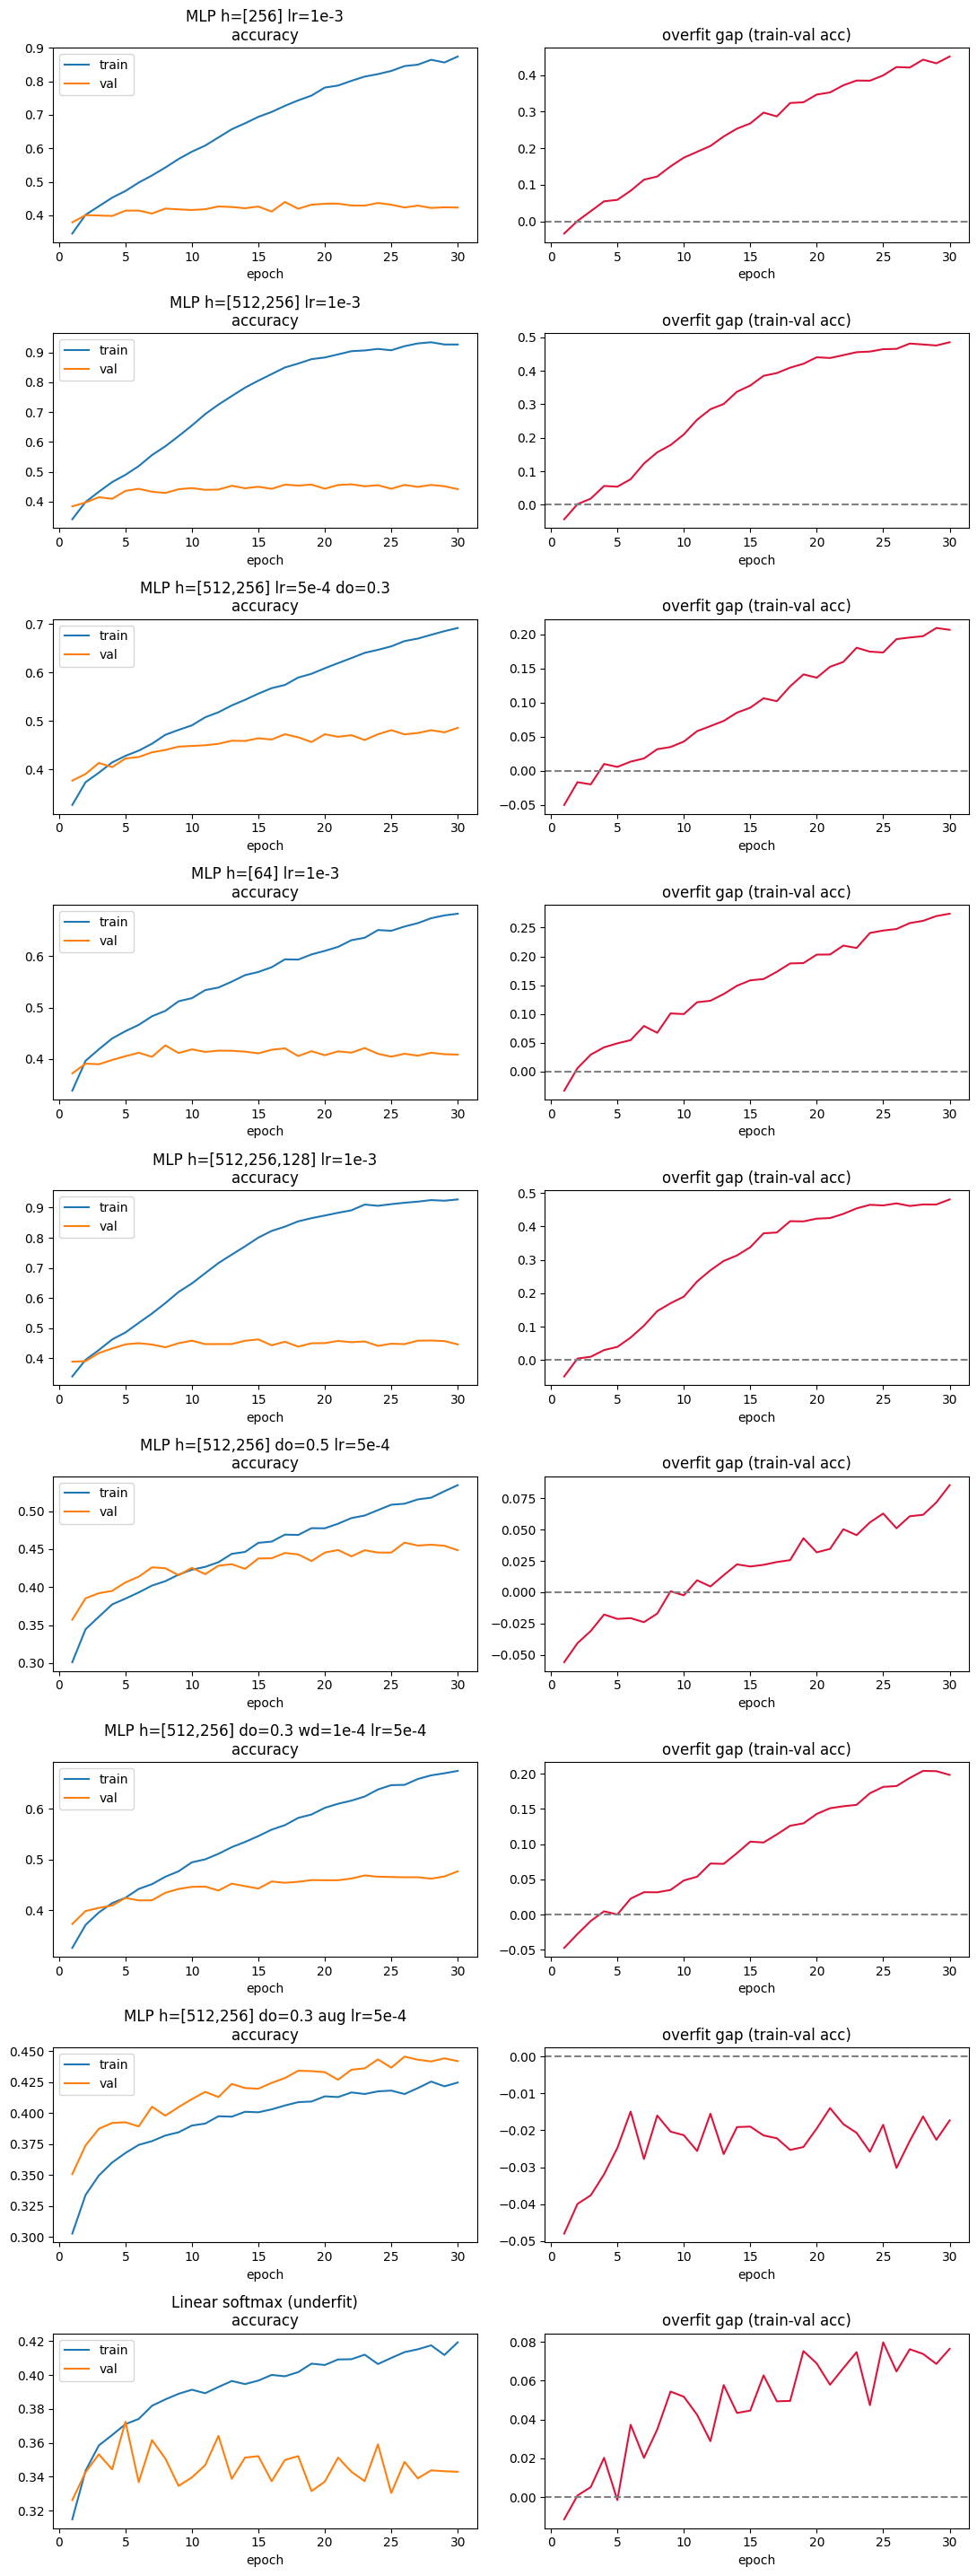

In [25]:
import matplotlib.pyplot as plt
n = len(HISTORY)
fig, axes = plt.subplots(n, 2, figsize=(11, 3.2 * n))
if n == 1: axes = axes.reshape(1, 2)
for row, (name, h) in zip(axes, HISTORY.items()):
    ep = range(1, len(h["train_acc"]) + 1)
    row[0].plot(ep, h["train_acc"], label="train")
    row[0].plot(ep, h["val_acc"], label="val")
    row[0].set_title(name + "\naccuracy"); row[0].set_xlabel("epoch"); row[0].legend()
    row[1].plot(ep, h["gap"], color="crimson"); row[1].axhline(0, ls="--", c="gray")
    row[1].set_title("overfit gap (train-val acc)"); row[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

,params,best_val_acc,test_acc,test_f1,final_gap
run,,,,,
MLP h=[256] lr=1e-3,591879,0.4400,0.4413,0.4389,0.4508
"MLP h=[512,256] lr=1e-3",1313287,0.4581,0.4558,0.4517,0.4849
"MLP h=[512,256] lr=5e-4 do=0.3",1313287,0.4857,0.4762,0.4763,0.2064
MLP h=[64] lr=1e-3,147975,0.4266,0.4218,0.3775,0.2742
"MLP h=[512,256,128] lr=1e-3",1345287,0.4631,0.4519,0.4446,0.4805
"MLP h=[512,256] do=0.5 lr=5e-4",1313287,0.4586,0.4544,0.4189,0.0856
"MLP h=[512,256] do=0.3 wd=1e-4 lr=5e-4",1313287,0.4767,0.4675,0.4533,0.1984
"MLP h=[512,256] do=0.3 aug lr=5e-4",1313287,0.4455,0.4436,0.3588,-0.0173
Linear softmax (underfit),16135,0.3725,0.3642,0.2888,0.0764


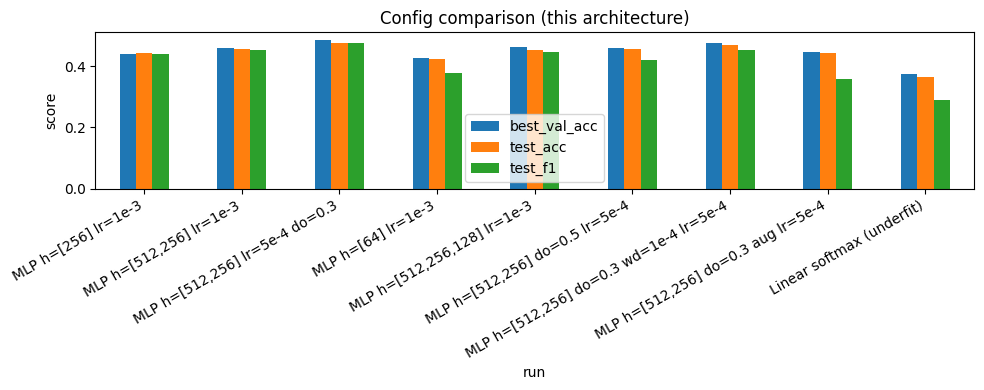

In [26]:
import pandas as pd
df = pd.DataFrame(SUMMARY).set_index("run")
display(df.round(4))
ax = df[["best_val_acc", "test_acc", "test_f1"]].plot(kind="bar", figsize=(10, 4))
ax.set_ylabel("score"); ax.set_title("Config comparison (this architecture)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

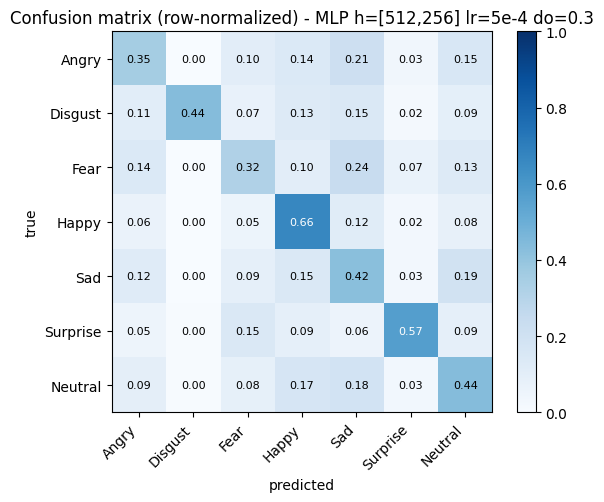

In [27]:
from sklearn.metrics import confusion_matrix
best = max(SUMMARY, key=lambda d: d["test_acc"])["run"]
yt, yp = CONF[best]
cm = confusion_matrix(yt, yp); cmn = cm / cm.sum(1, keepdims=True)
cls = [EMOTIONS[i] for i in range(NUM_CLASSES)]
fig, ax = plt.subplots(figsize=(6, 5)); im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(7)); ax.set_xticklabels(cls, rotation=45, ha="right")
ax.set_yticks(range(7)); ax.set_yticklabels(cls)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                color="white" if cmn[i, j] > 0.5 else "black", fontsize=8)
ax.set_title("Confusion matrix (row-normalized) - " + best)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.colorbar(im); plt.tight_layout(); plt.show()

In [28]:
from sklearn.metrics import classification_report
import pandas as pd
yt, yp = CONF[best]
rep = classification_report(yt, yp, target_names=[EMOTIONS[i] for i in range(7)],
                            output_dict=True, zero_division=0)
display(pd.DataFrame(rep).T.round(3))

,precision,recall,f1-score,support
Angry,0.379,0.352,0.365,491.000
Disgust,0.750,0.436,0.552,55.000
Fear,0.387,0.318,0.349,528.000
Happy,0.620,0.664,0.641,879.000
Sad,0.343,0.423,0.379,594.000
Surprise,0.680,0.567,0.619,416.000
Neutral,0.423,0.436,0.429,626.000
accuracy,0.476,0.476,0.476,0.476
macro avg,0.512,0.457,0.476,3589.000
weighted avg,0.481,0.476,0.476,3589.000
